# 🧬 Yeast Dataset Clustering Analysis

*Author:* JUSTINE UMUTONI 
---
**Course:** Unsupervised Learning - Evaluating Unsupervised Models  

# Overview
This notebook performs a comprehensive clustering analysis on the **Yeast dataset** (OpenML ID: 181), which contains 1,484 samples and 10 protein localization classes. 
---

In [1]:
# Cell 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.datasets import fetch_openml, make_blobs, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
)

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

In [2]:
# Cell 2: Load yeast dataset
X, y = fetch_openml(data_id=181, as_frame=True, return_X_y=True)

print("Yeast Dataset Info:")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {len(set(y))}")
print("\nClass distribution:")
for cls in sorted(set(y)):
    count = sum(y == cls)
    print(f"  {cls}: {count} ({count/len(y)*100:.1f}%)")

Yeast Dataset Info:
Samples: 1484, Features: 8
Classes: 10

Class distribution:
  CYT: 463 (31.2%)
  ERL: 5 (0.3%)
  EXC: 35 (2.4%)
  ME1: 44 (3.0%)
  ME2: 51 (3.4%)
  ME3: 163 (11.0%)
  MIT: 244 (16.4%)
  NUC: 429 (28.9%)
  POX: 20 (1.3%)
  VAC: 30 (2.0%)


In [3]:
# Cell 3: Standardize features (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized! Mean ≈ 0, Std ≈ 1")

Data standardized! Mean ≈ 0, Std ≈ 1


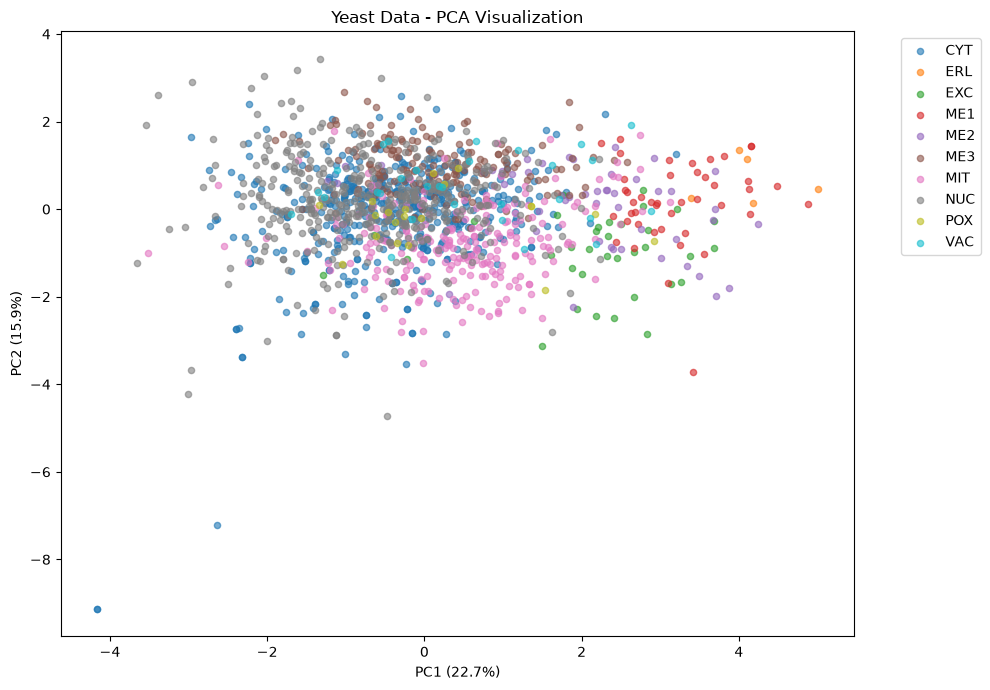

Saved: ../reports/yeast_pca.png


In [4]:
# Cell 4: PCA plot to visualize data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
for cls in sorted(set(y)):
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Yeast Data - PCA Visualization')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../reports/yeast_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../reports/yeast_pca.png")

In [5]:
# Cell 5: Simple function to find best k

def find_best_k(X, k_range=range(2, 11)):
    """Find best k using silhouette score and Davies-Bouldin score."""
    results = {}
    
    for k in k_range:
        # Run K-Means
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        
        results[k] = {'silhouette': sil, 'davies_bouldin': db}
        print(f"k={k}: Silhouette={sil:.3f}, Davies-Bouldin={db:.3f}")
    
    # Find best k
    best_sil = max(results, key=lambda k: results[k]['silhouette'])
    best_db = min(results, key=lambda k: results[k]['davies_bouldin'])
    
    print(f"\nBest k by Silhouette: {best_sil}")
    print(f"Best k by Davies-Bouldin: {best_db}")
    
    return results, best_sil, best_db

# Run on yeast data
print("="*50)
print("Finding best k for Yeast data")
print("="*50)
yeast_results, best_sil, best_db = find_best_k(X_scaled)

Finding best k for Yeast data
k=2: Silhouette=0.196, Davies-Bouldin=2.017
k=3: Silhouette=0.199, Davies-Bouldin=1.441
k=4: Silhouette=0.208, Davies-Bouldin=1.151
k=5: Silhouette=0.210, Davies-Bouldin=1.160
k=6: Silhouette=0.229, Davies-Bouldin=1.101
k=7: Silhouette=0.227, Davies-Bouldin=1.122
k=8: Silhouette=0.226, Davies-Bouldin=1.108
k=9: Silhouette=0.202, Davies-Bouldin=1.167
k=10: Silhouette=0.186, Davies-Bouldin=1.224

Best k by Silhouette: 6
Best k by Davies-Bouldin: 6


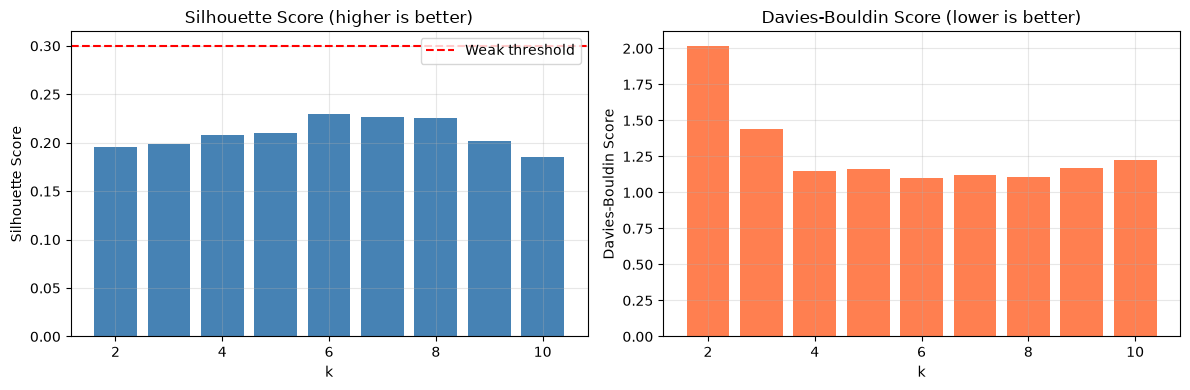

In [6]:
# Cell 6: Plot silhouette and Davies-Bouldin scores

k_values = list(yeast_results.keys())
sil_scores = [yeast_results[k]['silhouette'] for k in k_values]
db_scores = [yeast_results[k]['davies_bouldin'] for k in k_values]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Silhouette
ax1.bar(k_values, sil_scores, color='steelblue')
ax1.axhline(0.3, color='red', linestyle='--', label='Weak threshold')
ax1.set_xlabel('k')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score (higher is better)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Davies-Bouldin
ax2.bar(k_values, db_scores, color='coral')
ax2.set_xlabel('k')
ax2.set_ylabel('Davies-Bouldin Score')
ax2.set_title('Davies-Bouldin Score (lower is better)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/yeast_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Cell 7: Compare K-Means, GMM, and DBSCAN

k = best_sil  # Use best k from silhouette

print("="*50)
print(f"Comparing algorithms (k={k})")
print("="*50)

# K-Means
kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
labels_kmeans = kmeans.fit_predict(X_scaled)

# GMM
gmm = GaussianMixture(n_components=k, random_state=SEED)
labels_gmm = gmm.fit_predict(X_scaled)

# DBSCAN (try different eps values)
print("\nDBSCAN results:")
best_dbscan_sil = -1
best_dbscan_result = None

for eps in [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]:
    labels_db = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    noise_pct = 100 * (labels_db == -1).mean()
    
    if n_clusters > 1:
        mask = labels_db != -1
        sil = silhouette_score(X_scaled[mask], labels_db[mask])
        ari = adjusted_rand_score(y, labels_db)
        print(f"  eps={eps:.1f}: k={n_clusters}, noise={noise_pct:.1f}%, sil={sil:.3f}, ARI={ari:.3f}")
        
        if sil > best_dbscan_sil:
            best_dbscan_sil = sil
            best_dbscan_result = (eps, labels_db, n_clusters, noise_pct, sil, ari)

# Print summary
print("\nSummary:")
print(f"K-Means: Silhouette={silhouette_score(X_scaled, labels_kmeans):.3f}, ARI={adjusted_rand_score(y, labels_kmeans):.3f}")
print(f"GMM:     Silhouette={silhouette_score(X_scaled, labels_gmm):.3f}, ARI={adjusted_rand_score(y, labels_gmm):.3f}")
if best_dbscan_result:
    print(f"DBSCAN:  Silhouette={best_dbscan_result[4]:.3f}, ARI={best_dbscan_result[5]:.3f}")

Comparing algorithms (k=6)

DBSCAN results:
  eps=0.6: k=10, noise=77.6%, sil=0.101, ARI=-0.017
  eps=0.8: k=6, noise=43.6%, sil=0.035, ARI=0.036
  eps=1.2: k=2, noise=13.3%, sil=0.204, ARI=0.016
  eps=2.0: k=3, noise=2.3%, sil=0.711, ARI=0.012

Summary:
K-Means: Silhouette=0.229, ARI=0.136
GMM:     Silhouette=0.010, ARI=0.022
DBSCAN:  Silhouette=0.711, ARI=0.012


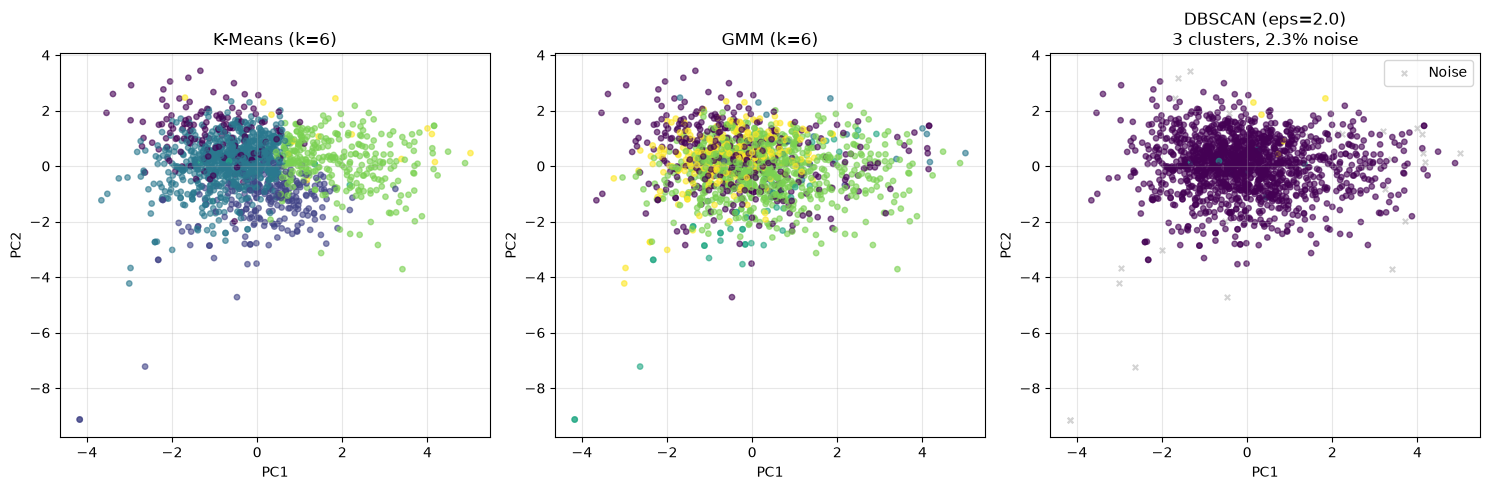

In [8]:
# Cell 8: Plot clustering results in PCA space

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# K-Means
ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.6, s=15)
ax.set_title(f'K-Means (k={k})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)

# GMM
ax = axes[1]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap='viridis', alpha=0.6, s=15)
ax.set_title(f'GMM (k={k})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)

# DBSCAN (best)
if best_dbscan_result:
    eps, labels_db, n_clusters, noise_pct, sil, ari = best_dbscan_result
    ax = axes[2]
    mask = labels_db != -1
    ax.scatter(X_pca[~mask, 0], X_pca[~mask, 1], c='lightgray', s=15, marker='x', label='Noise')
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=labels_db[mask], cmap='viridis', alpha=0.6, s=15)
    ax.set_title(f'DBSCAN (eps={eps:.1f})\n{n_clusters} clusters, {noise_pct:.1f}% noise')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Cell 9: Assignment Part 1 - Testing with different cluster overlap

print("="*50)
print("ASSIGNMENT PART 1: VARYING CLUSTER OVERLAP")
print("="*50)

for std in [1.0, 1.5, 2.0, 2.5, 3.0]:
    X_test, y_test = make_blobs(
        n_samples=1000,
        centers=4,
        n_features=2,
        cluster_std=std,
        random_state=SEED
    )
    
    # Find best k
    results, best_k, _ = find_best_k(X_test, range(2, 7))
    
    # Calculate ARI
    labels = KMeans(n_clusters=best_k, n_init=10, random_state=SEED).fit_predict(X_test)
    ari = adjusted_rand_score(y_test, labels)
    best_sil = max(results[k]['silhouette'] for k in results)
    
    print(f"\ncluster_std={std:.1f}: best_k={best_k}, sil={best_sil:.3f}, ARI={ari:.3f}")
    print("-"*40)

ASSIGNMENT PART 1: VARYING CLUSTER OVERLAP
k=2: Silhouette=0.590, Davies-Bouldin=0.529
k=3: Silhouette=0.752, Davies-Bouldin=0.360
k=4: Silhouette=0.792, Davies-Bouldin=0.292
k=5: Silhouette=0.654, Davies-Bouldin=0.673
k=6: Silhouette=0.530, Davies-Bouldin=0.903

Best k by Silhouette: 4
Best k by Davies-Bouldin: 4

cluster_std=1.0: best_k=4, sil=0.792, ARI=0.997
----------------------------------------
k=2: Silhouette=0.556, Davies-Bouldin=0.586
k=3: Silhouette=0.694, Davies-Bouldin=0.424
k=4: Silhouette=0.688, Davies-Bouldin=0.437
k=5: Silhouette=0.566, Davies-Bouldin=0.773
k=6: Silhouette=0.470, Davies-Bouldin=0.956

Best k by Silhouette: 3
Best k by Davies-Bouldin: 3

cluster_std=1.5: best_k=3, sil=0.694, ARI=0.711
----------------------------------------
k=2: Silhouette=0.520, Davies-Bouldin=0.655
k=3: Silhouette=0.634, Davies-Bouldin=0.496
k=4: Silhouette=0.596, Davies-Bouldin=0.568
k=5: Silhouette=0.514, Davies-Bouldin=0.761
k=6: Silhouette=0.412, Davies-Bouldin=0.988

Best k by 

ASSIGNMENT PART 2: UNEQUAL CLUSTERS
K-Means ARI: 0.987
DBSCAN ARI: 0.887
DBSCAN noise: 14.2%


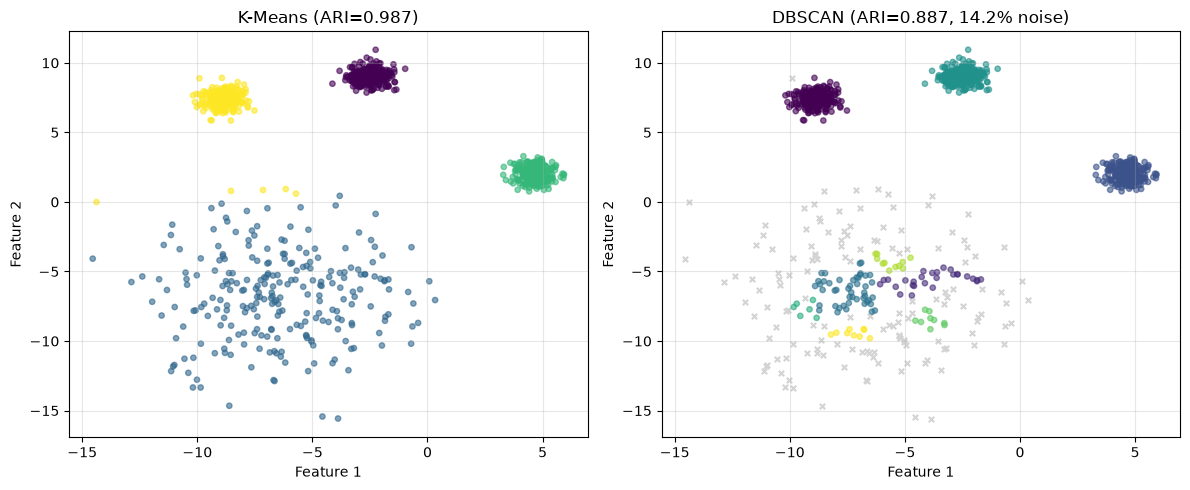

In [10]:
# Cell 10: Assignment Part 2 - Unequal cluster sizes

print("="*50)
print("ASSIGNMENT PART 2: UNEQUAL CLUSTERS")
print("="*50)

# Create data with one wide cluster
X_unequal, y_unequal = make_blobs(
    n_samples=1000,
    centers=4,
    n_features=2,
    cluster_std=[0.5, 0.5, 3.0, 0.5],
    random_state=SEED
)

# K-Means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=SEED)
labels_kmeans = kmeans.fit_predict(X_unequal)
ari_kmeans = adjusted_rand_score(y_unequal, labels_kmeans)

# DBSCAN
labels_dbscan = DBSCAN(eps=0.8, min_samples=8).fit_predict(X_unequal)
ari_dbscan = adjusted_rand_score(y_unequal, labels_dbscan)
noise_pct = 100 * (labels_dbscan == -1).mean()

print(f"K-Means ARI: {ari_kmeans:.3f}")
print(f"DBSCAN ARI: {ari_dbscan:.3f}")
print(f"DBSCAN noise: {noise_pct:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# K-Means
ax = axes[0]
ax.scatter(X_unequal[:, 0], X_unequal[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.6, s=15)
ax.set_title(f'K-Means (ARI={ari_kmeans:.3f})')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)

# DBSCAN
ax = axes[1]
mask = labels_dbscan != -1
ax.scatter(X_unequal[~mask, 0], X_unequal[~mask, 1], c='lightgray', s=15, marker='x')
ax.scatter(X_unequal[mask, 0], X_unequal[mask, 1], c=labels_dbscan[mask], cmap='viridis', alpha=0.6, s=15)
ax.set_title(f'DBSCAN (ARI={ari_dbscan:.3f}, {noise_pct:.1f}% noise)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/unequal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Cell 11: Assignment Part 3 - Pure noise

print("="*50)
print("ASSIGNMENT PART 3: NO STRUCTURE")
print("="*50)

# Generate pure noise
X_noise = np.random.normal(size=(1000, 2))

# Find best k
noise_results, noise_best_k, _ = find_best_k(X_noise, range(2, 7))

# Compare with structured data
X_struct, _ = make_blobs(n_samples=1000, centers=4, n_features=2, cluster_std=1.15, random_state=SEED)
struct_results, struct_best_k, _ = find_best_k(X_struct, range(2, 7))

struct_best_sil = max(struct_results[k]['silhouette'] for k in struct_results)
noise_best_sil = max(noise_results[k]['silhouette'] for k in noise_results)

print("\nComparison:")
print(f"Structured data: best sil={struct_best_sil:.3f} at k={struct_best_k}")
print(f"Noise data:      best sil={noise_best_sil:.3f} at k={noise_best_k}")
print("\nConclusion: Silhouette > 0.4 suggests real structure")

ASSIGNMENT PART 3: NO STRUCTURE
k=2: Silhouette=0.320, Davies-Bouldin=1.213
k=3: Silhouette=0.331, Davies-Bouldin=0.933
k=4: Silhouette=0.319, Davies-Bouldin=0.933
k=5: Silhouette=0.312, Davies-Bouldin=0.920
k=6: Silhouette=0.325, Davies-Bouldin=0.845

Best k by Silhouette: 3
Best k by Davies-Bouldin: 6
k=2: Silhouette=0.580, Davies-Bouldin=0.545
k=3: Silhouette=0.735, Davies-Bouldin=0.378
k=4: Silhouette=0.761, Davies-Bouldin=0.336
k=5: Silhouette=0.628, Davies-Bouldin=0.699
k=6: Silhouette=0.513, Davies-Bouldin=0.914

Best k by Silhouette: 4
Best k by Davies-Bouldin: 4

Comparison:
Structured data: best sil=0.761 at k=4
Noise data:      best sil=0.331 at k=3

Conclusion: Silhouette > 0.4 suggests real structure


ASSIGNMENT PART 4: FIND THE ELBOW
Elbow method suggests: k = 6
Silhouette suggests: k = 6
Agreement: Yes


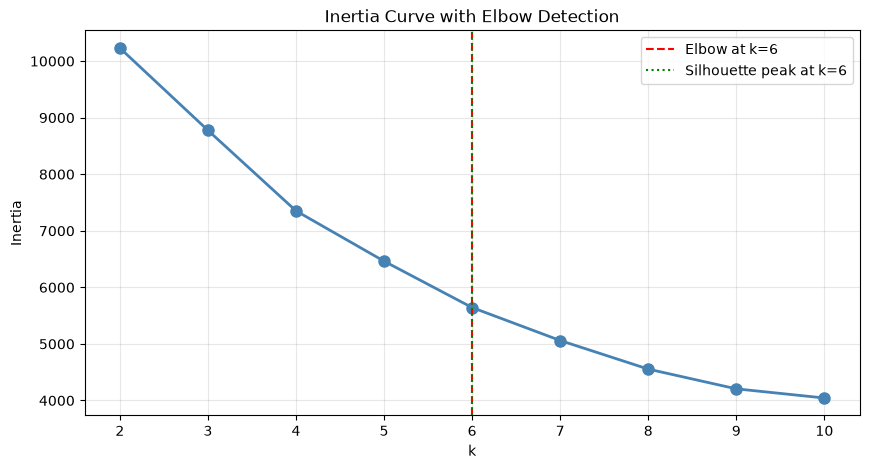

In [12]:
# Cell 12: Assignment Part 4 - Find the elbow

def find_elbow(inertias, k_range):
    """Find the elbow point on the inertia curve."""
    # Line from first to last point
    x1, y1 = k_range[0], inertias[0]
    x2, y2 = k_range[-1], inertias[-1]
    
    max_dist = -1
    elbow_k = None
    
    for i, k in enumerate(k_range):
        x, y = k, inertias[i]
        # Distance from point to line
        dist = abs((x2-x1)*(y1-y) - (x1-x)*(y2-y1)) / ((x2-x1)**2 + (y2-y1)**2)**0.5
        if dist > max_dist:
            max_dist = dist
            elbow_k = k
    
    return elbow_k

print("="*50)
print("ASSIGNMENT PART 4: FIND THE ELBOW")
print("="*50)

# Calculate inertia for yeast data
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

elbow_k = find_elbow(inertias, k_range)
sil_best_k = k_range[np.argmax(silhouettes)]

print(f"Elbow method suggests: k = {elbow_k}")
print(f"Silhouette suggests: k = {sil_best_k}")
print(f"Agreement: {'Yes' if elbow_k == sil_best_k else 'No'}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(elbow_k, color='red', linestyle='--', label=f'Elbow at k={elbow_k}')
plt.axvline(sil_best_k, color='green', linestyle=':', label=f'Silhouette peak at k={sil_best_k}')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Inertia Curve with Elbow Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../reports/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 13: Assignment Part 5 - Wine dataset

print("="*50)
print("ASSIGNMENT PART 5: WINE DATASET")
print("="*50)

# Load wine data
wine = load_wine()
X_wine = StandardScaler().fit_transform(wine.data)
y_wine = wine.target

print(f"Wine dataset: {X_wine.shape[0]} samples, {X_wine.shape[1]} features")
print(f"True classes: {len(wine.target_names)}")

# Find best k
wine_results, wine_best_sil, wine_best_db = find_best_k(X_wine, range(2, 8))

# Compare with true labels
labels = KMeans(n_clusters=wine_best_sil, n_init=10, random_state=SEED).fit_predict(X_wine)
ari = adjusted_rand_score(y_wine, labels)

print(f"\nBest k (silhouette): {wine_best_sil}")
print(f"Best k (Davies-Bouldin): {wine_best_db}")
print(f"True classes: {len(wine.target_names)}")
print(f"ARI with best k: {ari:.3f}")

ASSIGNMENT PART 5: WINE DATASET
Wine dataset: 178 samples, 13 features
True classes: 3
k=2: Silhouette=0.259, Davies-Bouldin=1.526
k=3: Silhouette=0.285, Davies-Bouldin=1.389
k=4: Silhouette=0.260, Davies-Bouldin=1.797
k=5: Silhouette=0.202, Davies-Bouldin=1.808
k=6: Silhouette=0.237, Davies-Bouldin=1.554
k=7: Silhouette=0.204, Davies-Bouldin=1.661

Best k by Silhouette: 3
Best k by Davies-Bouldin: 3

Best k (silhouette): 3
Best k (Davies-Bouldin): 3
True classes: 3
ARI with best k: 0.897
